In [1]:
import yfinance as yf
import pandas as pd

ticker = "AAPL"
start_date = "2023-01-01"
end_date = "2023-12-31"

df = yf.download(ticker, start=start_date, end=end_date, progress=False)

# Flatten columns if needed
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Ensure datetime index
df.index = pd.to_datetime(df.index)
df = df.sort_index()


C:\Users\weldi\AppData\Local\Temp\ipykernel_12004\4225635432.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import talib as ta


In [3]:
df['Daily_Return'] = df['Close'].pct_change()
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1


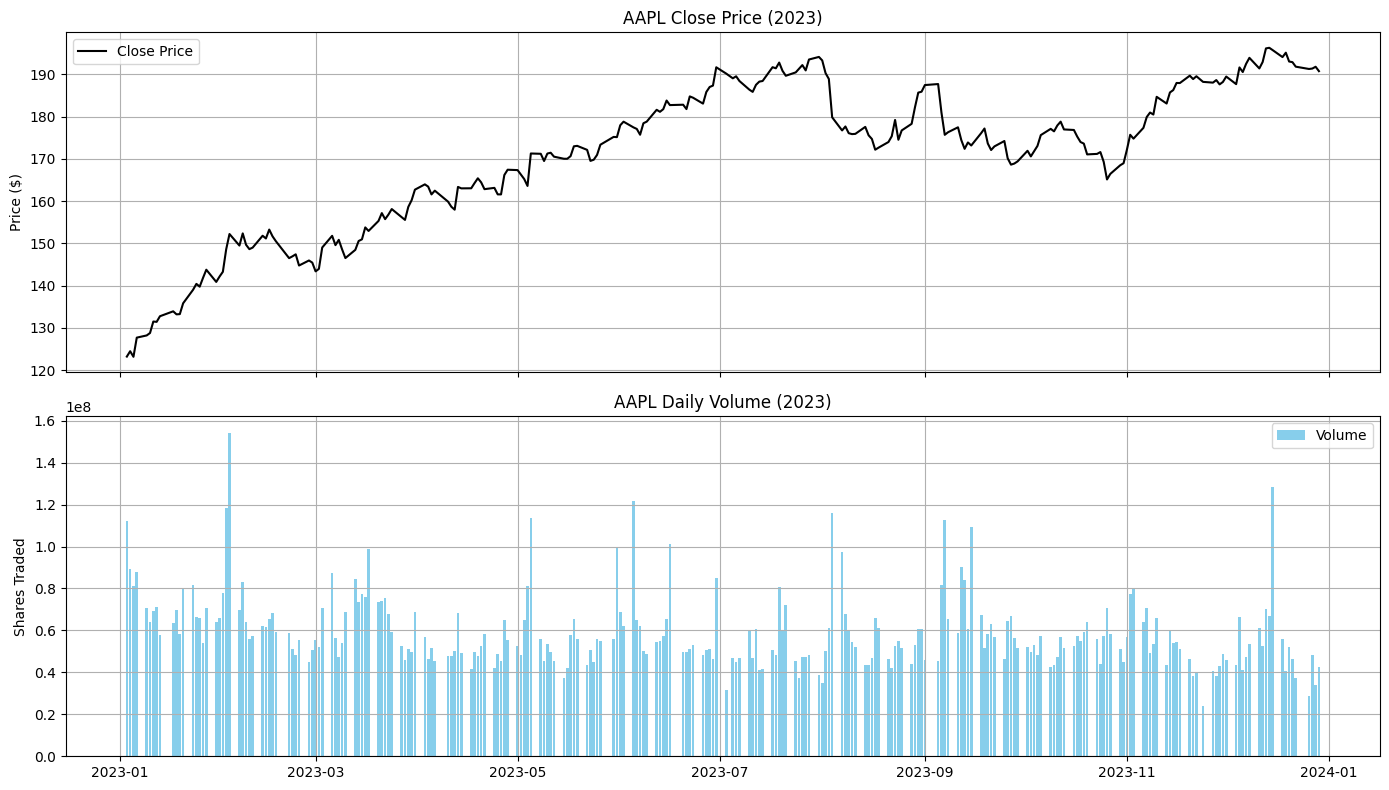

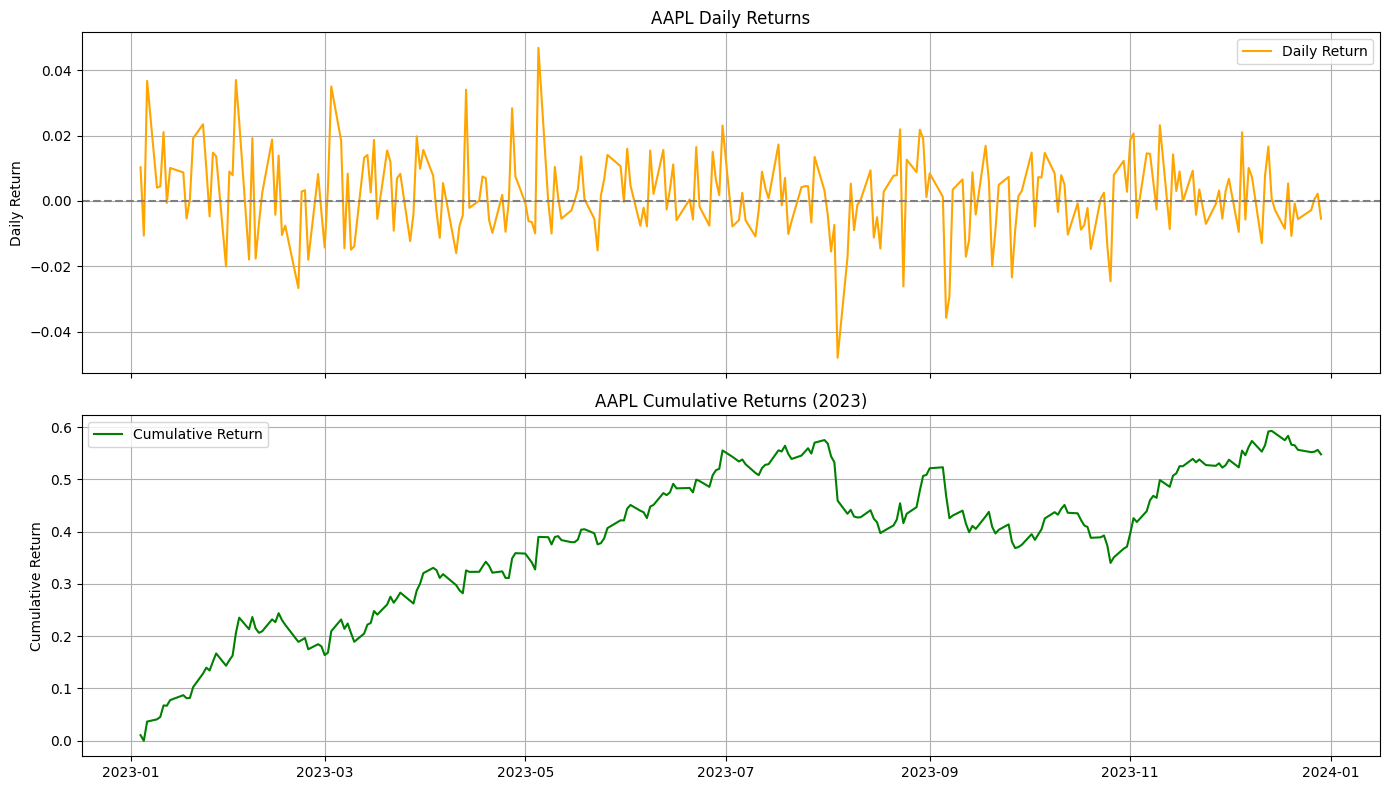

Descriptive statistics for Close, Daily Return, and Cumulative Return:
                   count        mean        std         min         25%  \
Price                                                                     
Close              250.0  170.510816  17.340362  123.161949  159.947029   
Daily_Return       249.0    0.001835   0.012570   -0.048020   -0.005891   
Cumulative_Return  249.0    0.385432   0.138889   -0.000400    0.300135   

                          50%         75%         max  
Price                                                  
Close              173.604622  185.426708  196.256577  
Daily_Return         0.001878    0.008846    0.046927  
Cumulative_Return    0.409121    0.506761    0.592847  


In [4]:

# Price, Volume, Daily Returns & Cumulative Returns

import matplotlib.pyplot as plt

# --- Price & Volume ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Close price
ax1.plot(df.index, df['Close'], color='black', label='Close Price')
ax1.set_ylabel('Price ($)')
ax1.set_title('AAPL Close Price (2023)')
ax1.legend()
ax1.grid(True)

# Volume
ax2.bar(df.index, df['Volume'], color='skyblue', label='Volume')
ax2.set_ylabel('Shares Traded')
ax2.set_title('AAPL Daily Volume (2023)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


# --- Daily Returns & Cumulative Returns ---
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily Returns
ax3.plot(df.index, df['Daily_Return'], color='orange', label='Daily Return')
ax3.set_ylabel('Daily Return')
ax3.set_title('AAPL Daily Returns')
ax3.axhline(0, color='gray', linestyle='--')
ax3.legend()
ax3.grid(True)

# Cumulative Returns
ax4.plot(df.index, df['Cumulative_Return'], color='green', label='Cumulative Return')
ax4.set_ylabel('Cumulative Return')
ax4.set_title('AAPL Cumulative Returns (2023)')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()


# Descriptive stats
print("Descriptive statistics for Close, Daily Return, and Cumulative Return:")
print(df[['Close','Daily_Return','Cumulative_Return']].describe().T)


In [5]:

# Technical Indicators 

import talib

# --- Clean numeric columns ---
for col in ['Close', 'Open', 'High', 'Low', 'Volume']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Use Adj Close if available ---
if "Adj Close" in df.columns:
    price = df["Adj Close"]
else:
    price = df["Close"]

# --- Moving Averages ---
df["SMA_20"] = talib.SMA(price, timeperiod=20)
df["SMA_50"] = talib.SMA(price, timeperiod=50)
df["EMA_20"] = talib.EMA(price, timeperiod=20)

# --- RSI ---
df["RSI_14"] = talib.RSI(price, timeperiod=14)

# --- MACD ---
df["MACD"], df["MACD_signal"], df["MACD_hist"] = talib.MACD(
    price, fastperiod=12, slowperiod=26, signalperiod=9
)

# --- Show the last rows (clean output) ---
df[['Close', 'SMA_20', 'SMA_50', 'EMA_20', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist']].tail(10)


Price,Close,SMA_20,SMA_50,EMA_20,RSI_14,MACD,MACD_signal,MACD_hist
Date,,,,,,,,
2023-12-15,195.721634,190.723324,181.953392,190.396862,67.991802,3.745910,3.574958,0.170952
2023-12-18,194.057327,191.030424,182.322576,190.745478,62.680124,3.582111,3.576389,0.005722
2023-12-19,195.097504,191.302355,182.682883,191.159957,64.544433,3.495934,3.560298,-0.064364
2023-12-20,193.007263,191.509896,183.013257,191.335891,58.247500,3.221834,3.492605,-0.270771
2023-12-21,192.858627,191.676817,183.312760,191.480913,57.815557,2.958510,3.385786,-0.427276
2023-12-22,191.788757,191.856619,183.572859,191.510232,54.672784,2.633141,3.235257,-0.602116
2023-12-26,191.243927,192.018096,183.858864,191.484869,53.090091,2.304752,3.049156,-0.744404
2023-12-27,191.342941,192.154309,184.149423,191.471352,53.354367,2.029102,2.845145,-0.816043
2023-12-28,191.768936,192.362839,184.479567,191.499694,54.540968,1.823995,2.640915,-0.816920


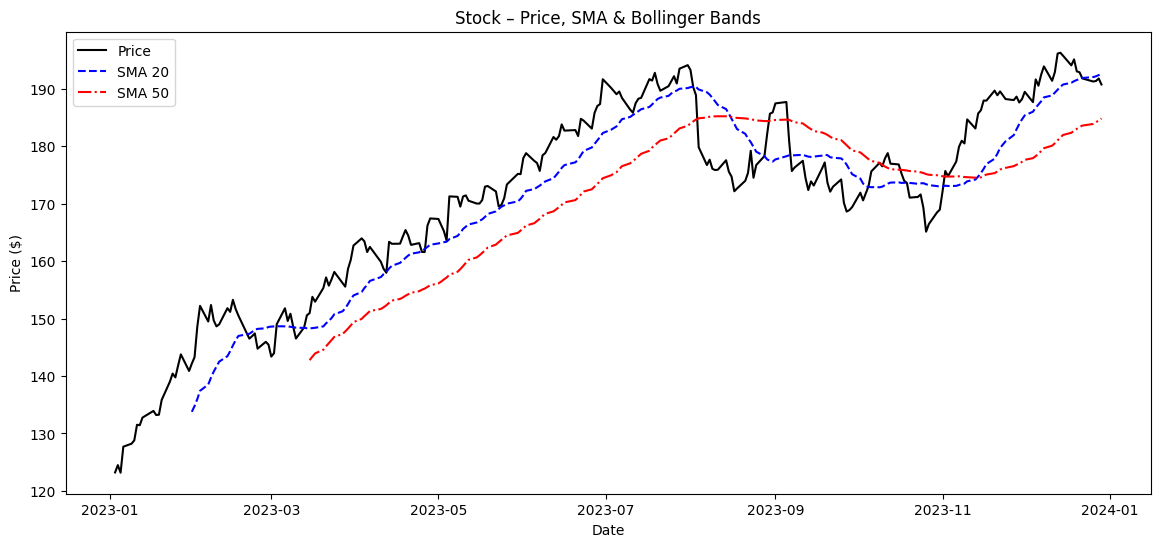

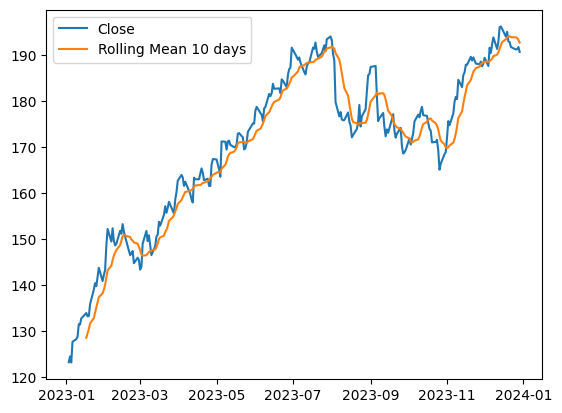

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['Close'], label="Price", color="black")

ax.plot(df.index, df["SMA_20"], label="SMA 20", linestyle="--", color="blue")
ax.plot(df.index, df["SMA_50"], label="SMA 50", linestyle="-.", color="red")

if 'upper_band' in df.columns and 'lower_band' in df.columns:
    ax.plot(df.index, df['upper_band'], label="Upper Band", linestyle=":", color="green")
    ax.plot(df.index, df['lower_band'], label="Lower Band", linestyle=":", color="green")
    ax.fill_between(df.index, df['lower_band'], df['upper_band'], color='green', alpha=0.1)

ax.set_title("Stock – Price, SMA & Bollinger Bands")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
plt.show()

df['Close_Rolling'] = df['Close'].rolling(window=10).mean()
plt.plot(df['Close'], label='Close')
plt.plot(df['Close_Rolling'], label='Rolling Mean 10 days')
plt.legend()
plt.show()



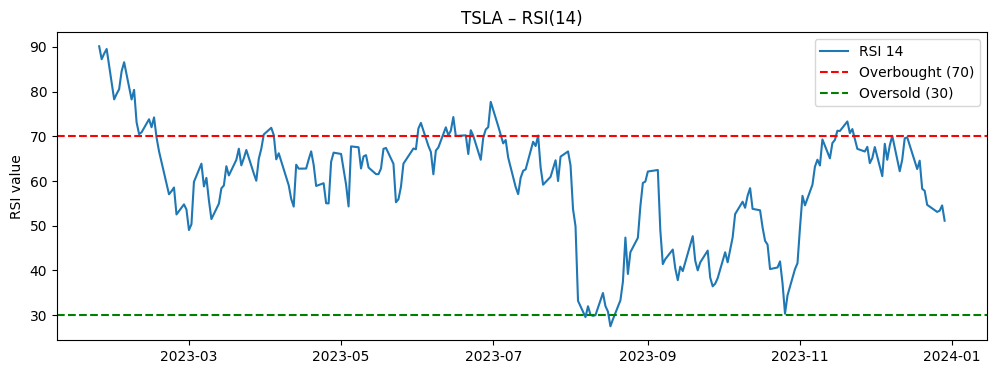

In [ ]:

# RSI – Overbought / Oversold


fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["RSI_14"], label="RSI 14")
ax.axhline(70, color="red", linestyle="--", label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", label="Oversold (30)")

ax.set_title("AAPL – RSI(14)")
ax.set_ylabel("RSI value")
ax.legend()
plt.show()


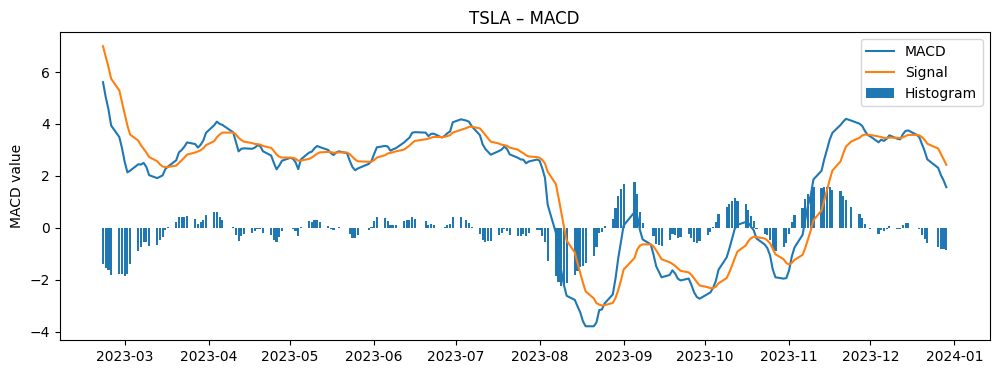

In [ ]:

# MACD – Trend & momentum

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["MACD"], label="MACD")
ax.plot(df.index, df["MACD_signal"], label="Signal")
ax.bar(df.index, df["MACD_hist"], label="Histogram")

ax.set_title("AAPL – MACD")
ax.set_ylabel("MACD value")
ax.legend()
plt.show()


In [ ]:
# Step 5: PyNance Portfolio Metrics
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from pynance import portfolio_optimizer as po

# Select tickers for your portfolio
ticker_list = ['TSLA', 'AAPL', 'MSFT']

# Create a PortfolioCalculations object
portfolio = po.PortfolioCalculations(ticker_list)

# Max Sharpe Portfolio
max_sharpe_rr = portfolio.max_sharpe_portfolio('rr')
max_sharpe_df = portfolio.max_sharpe_portfolio('df')
print("Max Sharpe Portfolio Risk/Return:")
print(max_sharpe_rr)
print("\nPortfolio Weights:")
print(max_sharpe_df)

# Min Variance Portfolio
min_var_rr = portfolio.min_var_portfolio('rr')
min_var_df = portfolio.min_var_portfolio('df')
print("\nMin Variance Portfolio Risk/Return:")
print(min_var_rr)
print("\nPortfolio Weights (Min Variance):")
print(min_var_df)

# Efficient Frontier Plot
fig = portfolio.efficient_frontier()
fig.show()


Max Sharpe Portfolio Risk/Return:
                   Max Sharpe Portfolio
Expected Return                  20.15%
Standard Deviation               20.34%

Portfolio Weights:
     Portfolio Weight
TSLA            0.00%
AAPL           39.94%
MSFT           60.06%

Min Variance Portfolio Risk/Return:
                   Min Var Portfolio
Expected Return               20.13%
Standard Deviation            20.33%

Portfolio Weights (Min Variance):
     Portfolio Weight
TSLA            0.00%
AAPL           42.07%
MSFT           57.93%
    Expected Return  Standard Deviation          TSLA      AAPL          MSFT
0            0.1972              0.2464  5.661913e-22  1.000000  1.666393e-16
1            0.1987              0.2233  5.551115e-17  0.804815  1.951848e-01
2            0.2001              0.2079  0.000000e+00  0.601145  3.988554e-01
3            0.2015              0.2034  0.000000e+00  0.397474  6.025259e-01
4            0.2029              0.2051  1.190019e-02  0.378576  6.095243e-01